# Track L — Public Transport Severe Delay Risk
EL-AZZOUNI Nada, HONG Jinan

## 1. Problem statement

MetroFlow is the public transport authority of a mid-sized city. A trip is called a severe delay when the vehicle arrives more than ten minutes late at its final stop. The goal of this project is to build a model that estimates, before a trip departs, the probability that the trip will end in a severe delay.

The prediction must be made with information available before departure: the schedule, the route, the traffic situation, the weather, the vehicle, and the dispatcher.

The problem is a binary classification problem. The target variable is `severe_delay`, which is 1 for a severe delay and 0 otherwise. The cost of the two error types is not symmetric:

- A missed delay (the model predicts on-time, the trip is delayed) means the dispatchers react too late.
- A false alarm (the model predicts a delay, the trip is on time) wastes reserve vehicles and dispatcher attention.

A useful model must therefore find an acceptable balance between these two errors. This trade-off is treated explicitly in Section 8, where the decision threshold is chosen.

Our notebook follows the suggested workflow: data inspection (Section 2), exploratory analysis (Section 3), evaluation methodology (Section 4), baselines (Section 5), logistic regression (Section 6), regularisation (Section 7), tree-based models (Section 8 part of comparison in Section 9), final model selection and test evaluation (Section 9), and limitations (Section 10).

## 2. Setup

This cell imports the libraries and fixes the random seed.

- `numpy` and `pandas` handle the numerical arrays and the tables.
- `matplotlib` and `seaborn` produce the plots.
- `scikit-learn` provides the models, the cross-validation tools, and the metrics.
- `scipy.stats.pointbiserialr` computes the point-biserial correlation used in Section 3.

The constant `RANDOM_STATE = 42` is passed to every operation that involves randomness (train/validation split, cross-validation shuffling, model initialisation). With a fixed seed, every run of the notebook produces exactly the same numbers. This makes the results reproducible.

Two small helper functions are defined here because they are used several times later:

- `print_metrics(y_true, y_pred)` prints accuracy, precision, recall and F1 for a set of hard predictions.
- `cv_scores(model, X, y)` runs 5-fold stratified cross-validation and returns the mean and standard deviation of ROC-AUC and PR-AUC. Defining it once avoids repeating the same code for every model.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from scipy.stats import pointbiserialr

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
warnings.filterwarnings("ignore", category=FutureWarning)
# scikit-learn >= 1.8 emits a deprecation notice for penalty="l1"/"l2" with
# the liblinear solver; the parameter still works on all current versions
warnings.filterwarnings("ignore", message=".*penalty is deprecated.*")

BLUE, RED, GREEN = "#4C72B0", "#C44E52", "#55A868"

def print_metrics(y_true, y_pred):
    print(f"  accuracy  = {accuracy_score(y_true, y_pred):.3f}")
    print(f"  precision = {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"  recall    = {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"  F1        = {f1_score(y_true, y_pred, zero_division=0):.3f}")

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_scores(model, X, y):
    roc = cross_val_score(model, X, y, cv=CV, scoring="roc_auc")
    pr  = cross_val_score(model, X, y, cv=CV, scoring="average_precision")
    return roc.mean(), roc.std(), pr.mean(), pr.std()

print("setup complete")

setup complete


## 3. Loading and checking the data

Before any analysis, the two files are loaded and four basic properties are checked. Each check has a precise purpose:

1. Shape (rows and columns) : This tells us how much data is available. With few rows, complex models would overfit.
2. Data types : All features must be numeric before they can be given to the models. If a column were stored as text, it would need conversion.
3. Missing values : A missing value is an empty cell. Models cannot handle them directly, so if any existed they would have to be filled (imputed) or the rows dropped.
4. Duplicate rows : Identical repeated rows would give extra weight to whatever they contain and could leak information between training and validation folds.

The class balance of the target is also computed, because it determines which evaluation metrics are appropriate (Section 4).

In [2]:
train_df = pd.read_csv("track_l_public_transport_delay_train.csv")
test_df  = pd.read_csv("track_l_public_transport_delay_test.csv")

print("train shape:", train_df.shape)
print("test  shape:", test_df.shape)
print()
print("column dtypes:")
print(train_df.dtypes)
print()
train_df.head()

train shape: (1500, 13)
test  shape: (400, 13)

column dtypes:
scheduled_hour                   int64
route_length_km                float64
num_stops                        int64
traffic_density_index          float64
road_congestion_pct            float64
rain_mm                        float64
wind_speed_m_s                 float64
temperature_c                  float64
vehicle_age_years              float64
incidents_last_24h               int64
dispatcher_experience_years    float64
line_brand_color                 int64
severe_delay                     int64
dtype: object



,scheduled_hour,route_length_km,num_stops,traffic_density_index,road_congestion_pct,rain_mm,wind_speed_m_s,temperature_c,vehicle_age_years,incidents_last_24h,dispatcher_experience_years,line_brand_color,severe_delay
0,2,26.42,29,11.40,13.48,3.54,1.38,36.97,20.71,1,19.21,3,0
1,18,13.43,19,28.60,34.38,4.92,7.29,-0.42,15.41,1,4.09,4,1
2,15,13.26,15,38.11,18.81,4.72,10.96,4.25,5.85,0,3.64,5,1
3,10,9.42,21,26.04,19.19,3.33,10.62,-3.56,19.94,1,9.58,4,0
4,10,45.24,16,11.81,10.98,1.13,3.27,28.97,7.57,0,4.66,3,0


In [3]:
print("missing values  - train:", int(train_df.isnull().sum().sum()),
      "| test:", int(test_df.isnull().sum().sum()))
print("duplicate rows  - train:", int(train_df.duplicated().sum()),
      "| test:", int(test_df.duplicated().sum()))
print()
print("target balance (train):")
print(train_df["severe_delay"].value_counts(normalize=True).round(4))
print()
print("target balance (test):")
print(test_df["severe_delay"].value_counts(normalize=True).round(4))

missing values  - train: 0 | test: 0
duplicate rows  - train: 0 | test: 0

target balance (train):
severe_delay
0    0.796
1    0.204
Name: proportion, dtype: float64

target balance (test):
severe_delay
0    0.7975
1    0.2025
Name: proportion, dtype: float64


In [4]:
# Descriptive statistics of every column, transposed for readability
train_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
scheduled_hour,1500.0,11.62,6.95,0.00,6.00,12.00,18.00,23.00
route_length_km,1500.0,25.00,13.37,2.02,13.35,24.39,36.80,47.99
num_stops,1500.0,23.42,11.86,4.00,13.00,23.00,34.00,44.00
traffic_density_index,1500.0,53.24,25.41,10.08,31.29,52.46,74.46,99.97
road_congestion_pct,1500.0,42.12,21.80,5.00,24.72,41.35,58.75,100.00
rain_mm,1500.0,3.05,2.63,0.01,1.13,2.30,4.23,21.37
wind_speed_m_s,1500.0,8.89,5.07,0.00,4.43,8.98,13.06,18.00
temperature_c,1500.0,15.84,13.16,-7.97,4.74,16.34,27.45,37.99
vehicle_age_years,1500.0,11.11,6.46,0.00,5.57,11.19,16.65,21.99
incidents_last_24h,1500.0,1.12,1.07,0.00,0.00,1.00,2.00,6.00


### Findings

- The training set has 1500 rows and the test set has 400 rows. Each row has 12 features plus the target, so 13 columns.
- All columns are numeric (`int64` or `float64`). No type conversion is needed.
- There are no missing values and no duplicate rows in either file. No cleaning is needed.
- The target is imbalanced: about 20% of trips are severe delays in the training set and about the same in the test set. The two files have the same class balance, which means the test set is representative of the training set in this respect.
- The descriptive statistics match the ranges given in the feature reference (for example `scheduled_hour` runs from 0 to 23 and `rain_mm` from 0 to about 25). No value falls outside its documented range, so there are no impossible entries to correct.

Because the test set must simulate genuinely unseen future trips, it is now set aside. Every decision in Sections 3 to 8 (feature analysis, model choice, hyperparameters, threshold) is made using the training set only. The test set is touched exactly once, in Section 9.

## 4. Exploratory data analysis

The goal of this section is to understand the data before modelling, so that the modelling choices are based on evidence instead of guesses. Five questions are answered, one per subsection:

1. How imbalanced is the target? (4.1)
2. What does the distribution of each feature look like — is there skew or are there outliers? (4.2)
3. Are some features strongly correlated with each other (multicollinearity)? (4.3)
4. Which features are related to the target, linearly (4.4) and non-linearly (4.5)?
5. What do the most informative features look like when split by delay status? (4.6 and 4.7)

The answers to these questions decide which metrics to use, whether scaling is needed, whether regularisation is likely to matter, and how much non-linear models can be expected to help.

### 4.1 Class balance

The bar chart below shows the number of on-time trips and severely delayed trips, for the training file and the test file side by side. The purpose is to see the imbalance directly, not only as a percentage.

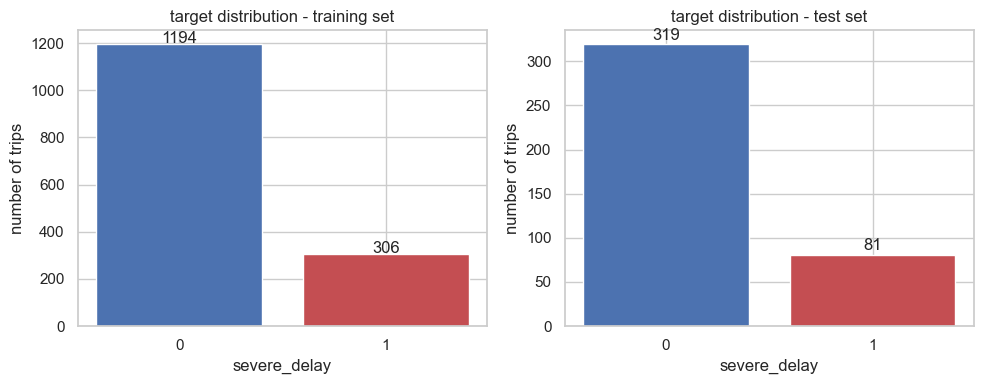

delay rate train: 0.204
delay rate test : 0.203


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, name in zip(axes, [train_df, test_df], ["training set", "test set"]):
    counts = df["severe_delay"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=[BLUE, RED])
    ax.set_title(f"target distribution - {name}")
    ax.set_xlabel("severe_delay")
    ax.set_ylabel("number of trips")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"delay rate train: {train_df['severe_delay'].mean():.3f}")
print(f"delay rate test : {test_df['severe_delay'].mean():.3f}")

The ratio of on-time to delayed trips is roughly 4 to 1 in both files. This has a direct consequence for evaluation: a model that always predicts "on-time" would be correct about 80% of the time while being completely useless. Plain accuracy is therefore not a suitable metric for this problem. Section 4 (evaluation methodology) builds the scoring around precision, recall and ranking metrics instead.

### 4.2 Feature distributions

One histogram is drawn per feature. Two things are checked:

- Skew: an asymmetric distribution with a long tail on one side. Skewness is quantified below for the continuous features; a value of 0 means symmetric, values above about 1 mean clearly right-skewed.
- Outliers: a few values far away from the rest.

Both matter mainly for linear models, because extreme values can pull the fitted coefficients. Tree-based models split on thresholds and are insensitive to skew and outliers.

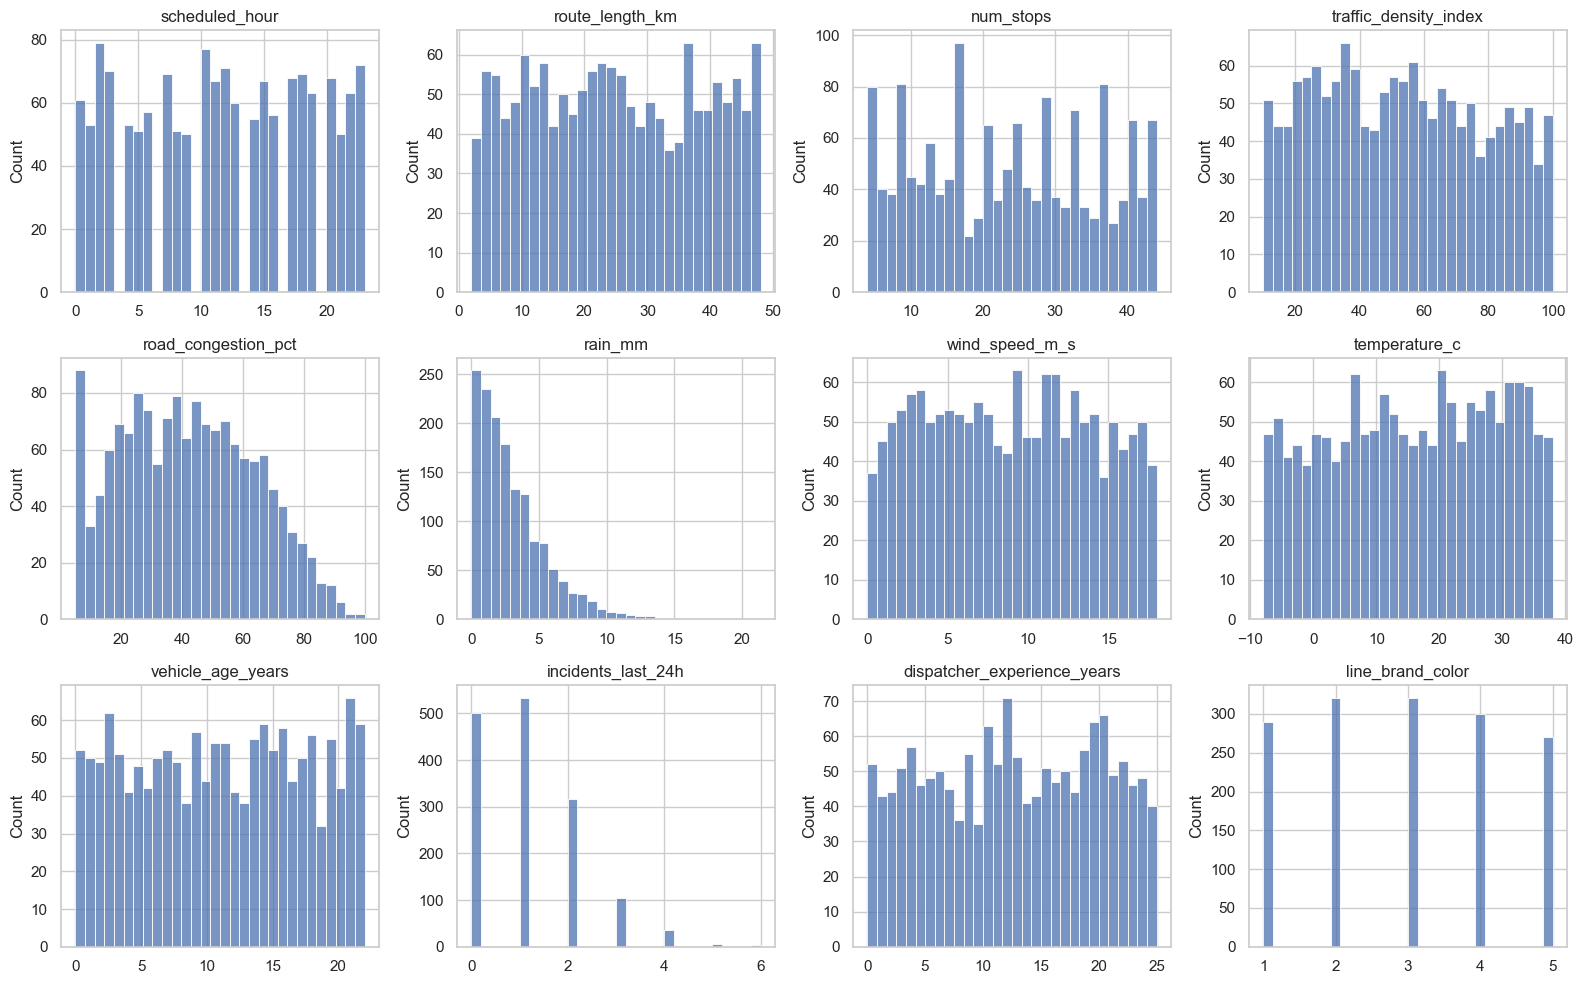

skewness of the continuous features:
rain_mm                        1.66
road_congestion_pct            0.17
traffic_density_index          0.11
route_length_km                0.05
wind_speed_m_s                 0.03
vehicle_age_years             -0.02
dispatcher_experience_years   -0.06
temperature_c                 -0.10
dtype: float64


In [6]:
features = [c for c in train_df.columns if c != "severe_delay"]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(train_df[col], bins=30, ax=ax, color=BLUE)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

continuous = ["route_length_km", "traffic_density_index", "road_congestion_pct",
              "rain_mm", "wind_speed_m_s", "temperature_c",
              "vehicle_age_years", "dispatcher_experience_years"]
print("skewness of the continuous features:")
print(train_df[continuous].skew().round(2).sort_values(ascending=False))

Most features are roughly symmetric and spread evenly over their documented range. The exception is `rain_mm`: most trips have little or no rain, and a small number of trips have heavy rain, which produces a long right tail (skewness about 1.7). This is the natural shape for rainfall data and does not need to be corrected; it is simply noted so that the result is not mistaken for a data error. None of the features show isolated impossible outliers.

Because the features live on very different scales (for example `scheduled_hour` from 0 to 23 versus `traffic_density_index` from 10 to 100), the linear models in Sections 6 and 7 will use standardisation (subtracting the mean and dividing by the standard deviation of each feature). Without it, features with large numeric ranges would dominate the regularisation penalty for no good reason.

### 4.3 Correlation between features

The heatmap below shows the Pearson correlation between every pair of numeric columns. Pearson correlation runs from −1 to +1. A value near +1 means the two variables increase together; near −1 means one increases when the other decreases; near 0 means there is no linear relationship.

The purpose of this check is to detect multicollinearity: two features that carry almost the same information. Multicollinearity does not reduce the predictive performance of a linear model, but it makes the individual coefficients unstable and hard to interpret, and it is the standard motivation for regularisation (Section 7). `line_brand_color` is excluded from the heatmap because it is a categorical identifier, so a Pearson correlation computed on it would not mean anything.

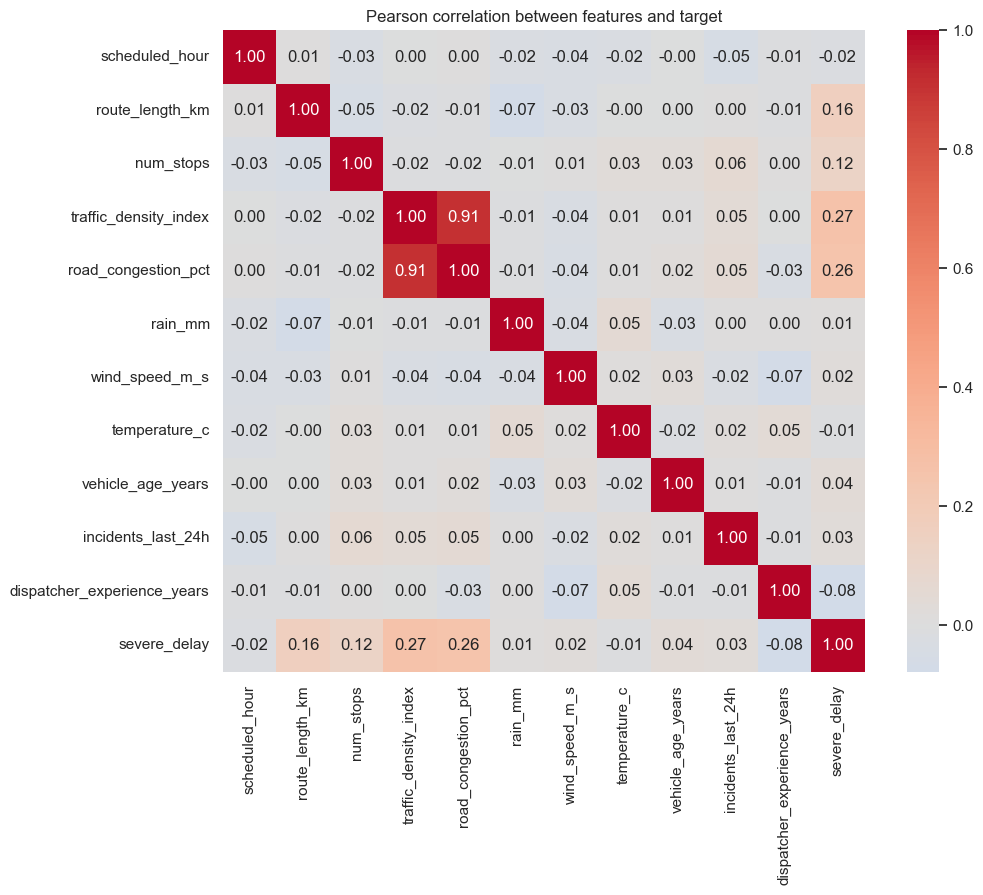

In [7]:
corr_cols = [c for c in train_df.columns if c != "line_brand_color"]
corr = train_df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Pearson correlation between features and target")
plt.tight_layout()
plt.show()

One pair stands out: `traffic_density_index` and `road_congestion_pct` have a correlation of 0.91. This is expected, since both measure how busy the roads are. It is the only serious case of multicollinearity in the data. Two consequences are noted for later:

1. The coefficients of these two features in the logistic regression should not be interpreted individually, because the model can distribute their shared effect between them arbitrarily.
2. This pair is the concrete reason to test L1 and L2 regularisation in Section 7.

The last row of the heatmap also gives a first view of the feature-target relationships, which the next subsection measures properly.

### 4.4 Linear relationship between each feature and the target

The target is binary and the features are numeric, so the appropriate measure is the point-biserial correlation. It is mathematically identical to the Pearson correlation between a numeric variable and a 0/1 variable. It answers the question: when this feature increases, does the delay rate increase or decrease, and by how much?

For each feature the p-value is also reported. The p-value is the probability of observing a correlation at least this large if the feature were in reality unrelated to the target. A small p-value (below 0.05 is the usual convention) means the relationship is unlikely to be a coincidence of this particular sample.

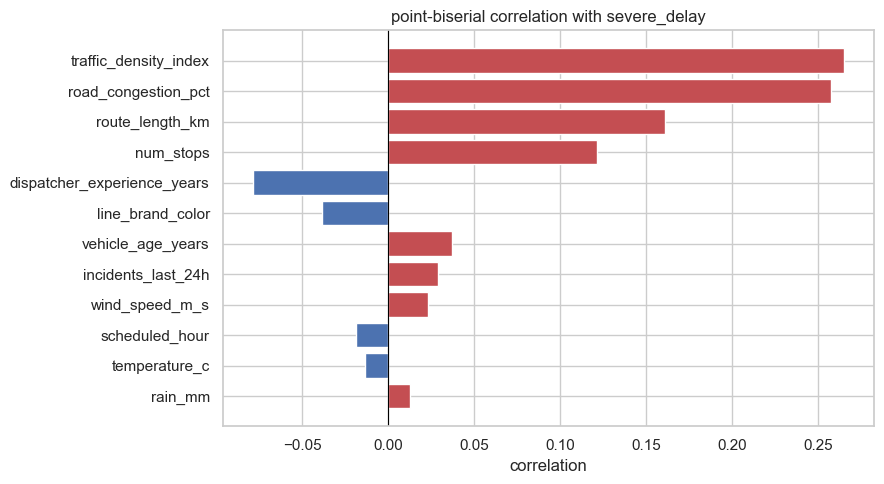

,feature,point_biserial_r,p_value
0,traffic_density_index,0.2655,0.0000
1,road_congestion_pct,0.2577,0.0000
2,route_length_km,0.1609,0.0000
3,num_stops,0.1214,0.0000
4,dispatcher_experience_years,-0.0790,0.0022
5,line_brand_color,-0.0386,0.1353
6,vehicle_age_years,0.0370,0.1521
7,incidents_last_24h,0.0289,0.2626
8,wind_speed_m_s,0.0232,0.3691
9,scheduled_hour,-0.0189,0.4646


In [8]:
y_full = train_df["severe_delay"]
X_full = train_df.drop(columns="severe_delay")

rows = []
for c in X_full.columns:
    r, p = pointbiserialr(X_full[c], y_full)
    rows.append({"feature": c, "point_biserial_r": r, "p_value": p})
pb = pd.DataFrame(rows)
pb = pb.reindex(pb["point_biserial_r"].abs()
                .sort_values(ascending=False).index).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if v > 0 else BLUE for v in pb["point_biserial_r"]]
ax.barh(pb["feature"], pb["point_biserial_r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("point-biserial correlation with severe_delay")
ax.set_xlabel("correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

pb.round(4)

The features split into two groups:

- Four features show a real relationship with the target: `traffic_density_index` (r ≈ 0.27), `road_congestion_pct` (r ≈ 0.26), `route_length_km` (r ≈ 0.16) and `num_stops` (r ≈ 0.12). All four have p-values below 0.001. The direction is operationally sensible: denser traffic, more congestion, longer routes and more stops all go with more delays.
- The remaining eight features have correlations near zero and p-values well above 0.05. On this linear measure they are indistinguishable from noise.

Even the strongest correlations are modest (0.27 is a weak correlation in absolute terms). This already suggests that no model will separate the two classes cleanly, because the available features simply do not contain that much information about the outcome.

### 4.5 Non-linear relationship check with mutual information

The point-biserial correlation only detects straight-line relationships. A feature could have zero correlation and still matter in a non-linear way, for example if delays only occur above some threshold of rain. To check for this, mutual information is computed between each feature and the target.

Mutual information measures how much knowing the value of the feature reduces the uncertainty about the target, for any shape of relationship. It is 0 when the feature and the target are independent, and larger values mean stronger dependence. The genuinely discrete columns are flagged as discrete so the estimator treats them correctly.

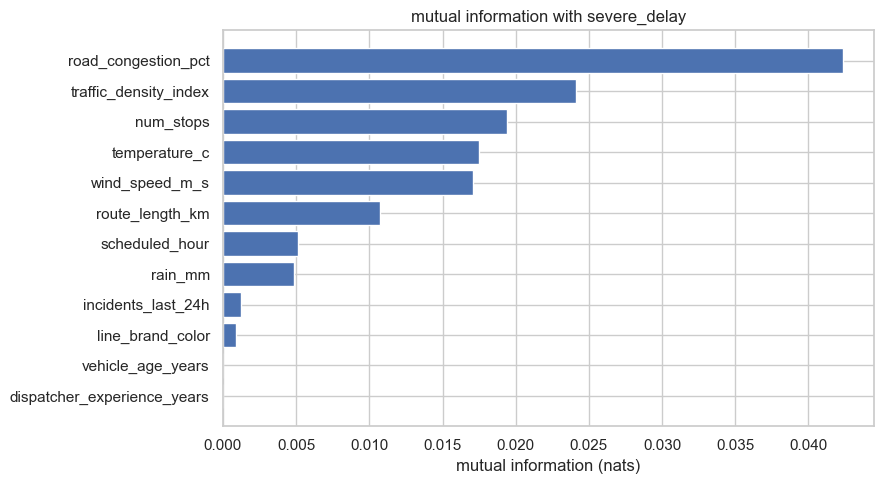

road_congestion_pct            0.0424
traffic_density_index          0.0241
num_stops                      0.0194
temperature_c                  0.0175
wind_speed_m_s                 0.0171
route_length_km                0.0108
scheduled_hour                 0.0051
rain_mm                        0.0048
incidents_last_24h             0.0013
line_brand_color               0.0009
vehicle_age_years              0.0000
dispatcher_experience_years    0.0000
dtype: float64

In [9]:
discrete_cols = ["scheduled_hour", "num_stops", "incidents_last_24h", "line_brand_color"]
discrete_mask = [c in discrete_cols for c in X_full.columns]

mi = mutual_info_classif(X_full, y_full, discrete_features=discrete_mask,
                         random_state=RANDOM_STATE)
mi_ser = pd.Series(mi, index=X_full.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_ser.index, mi_ser.values, color=BLUE)
ax.set_title("mutual information with severe_delay")
ax.set_xlabel("mutual information (nats)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mi_ser.round(4)

The mutual-information ranking agrees with the linear ranking: the traffic pair and the route-size pair (`route_length_km`, `num_stops`) are at the top, and the weather, vehicle and dispatcher features are at or near zero. The agreement between the two measures is informative: if a feature had a strong non-linear effect, mutual information would rank it high while the correlation would not. No feature shows that pattern. The conclusion is that there is little hidden non-linear structure for a flexible model to exploit. This is a testable prediction: if it is true, the tree-based models in Section 8 should not beat logistic regression. Section 8 performs that test.

### 4.6 The four informative features, split by delay status

A correlation is one number and does not show the shape of the relationship. The box plots below show the distribution of each of the four informative features, separately for on-time trips and delayed trips. The box covers the middle 50% of values and the line inside it is the median. The important thing to look at is the overlap between the two boxes: the more they overlap, the harder it is to separate the classes using that feature.

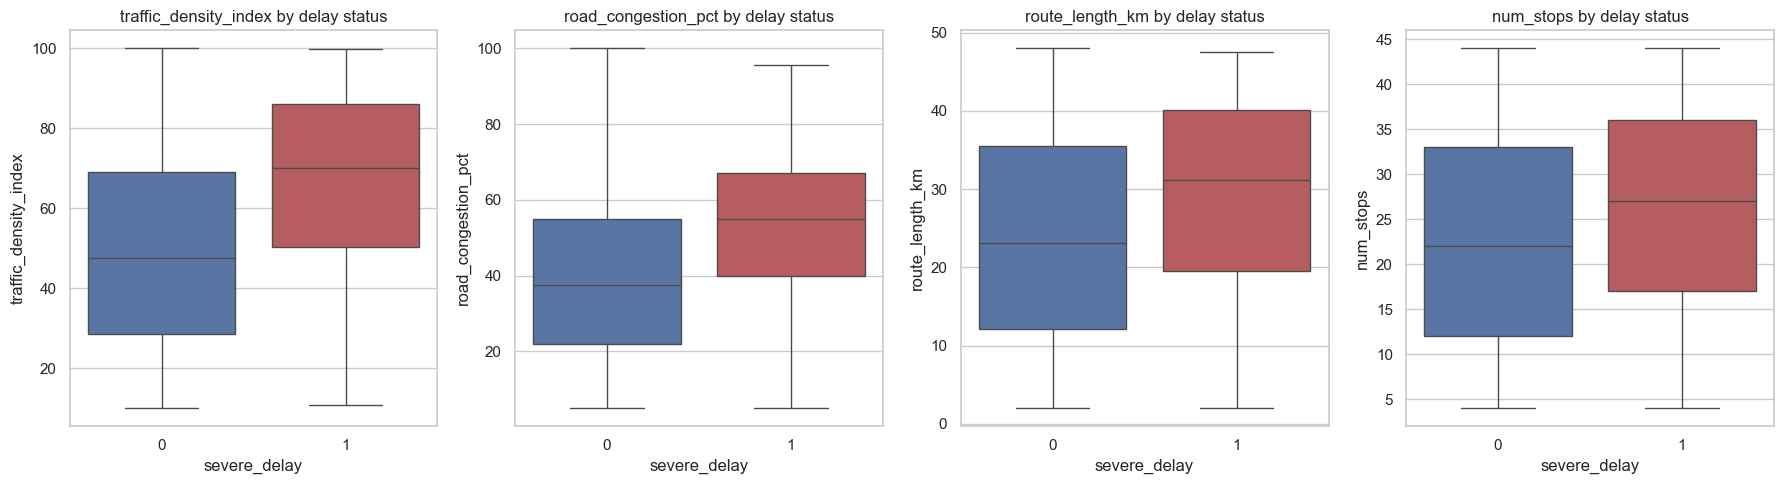

median values per class:
              traffic_density_index  road_congestion_pct  route_length_km  \
severe_delay                                                                
0                             47.50                37.43            23.12   
1                             70.17                54.92            31.23   

              num_stops  
severe_delay             
0                  22.0  
1                  27.0  


In [10]:
top_continuous = ["traffic_density_index", "road_congestion_pct",
                  "route_length_km", "num_stops"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, top_continuous):
    sns.boxplot(data=train_df, x="severe_delay", y=col, hue="severe_delay",
                palette=[BLUE, RED], legend=False, ax=ax)
    ax.set_title(f"{col} by delay status")
    ax.set_xlabel("severe_delay")
plt.tight_layout()
plt.show()

print("median values per class:")
print(train_df.groupby("severe_delay")[top_continuous].median().round(2))

For all four features, the median is higher for delayed trips, in the direction the correlations predicted. But the boxes overlap heavily in every plot: the difference between the two groups is small compared to the spread inside each group. This is the visual form of the weak correlations found in 4.4. Many delayed trips look, on these features, exactly like on-time trips. No threshold on any single feature would separate the classes well.

### 4.7 The category-like features

Three features are category-like rather than continuous: `incidents_last_24h` (small counts), `line_brand_color` (an identifier from 1 to 5) and `scheduled_hour` (which is grouped here into five time-of-day bands: night, morning peak, midday, evening peak, evening). For each, the plot shows the delay rate per level, that is the fraction of trips at that level that ended in a severe delay. The dashed line is the overall delay rate of about 20%. If a feature mattered, the delay rate would differ clearly between its levels.

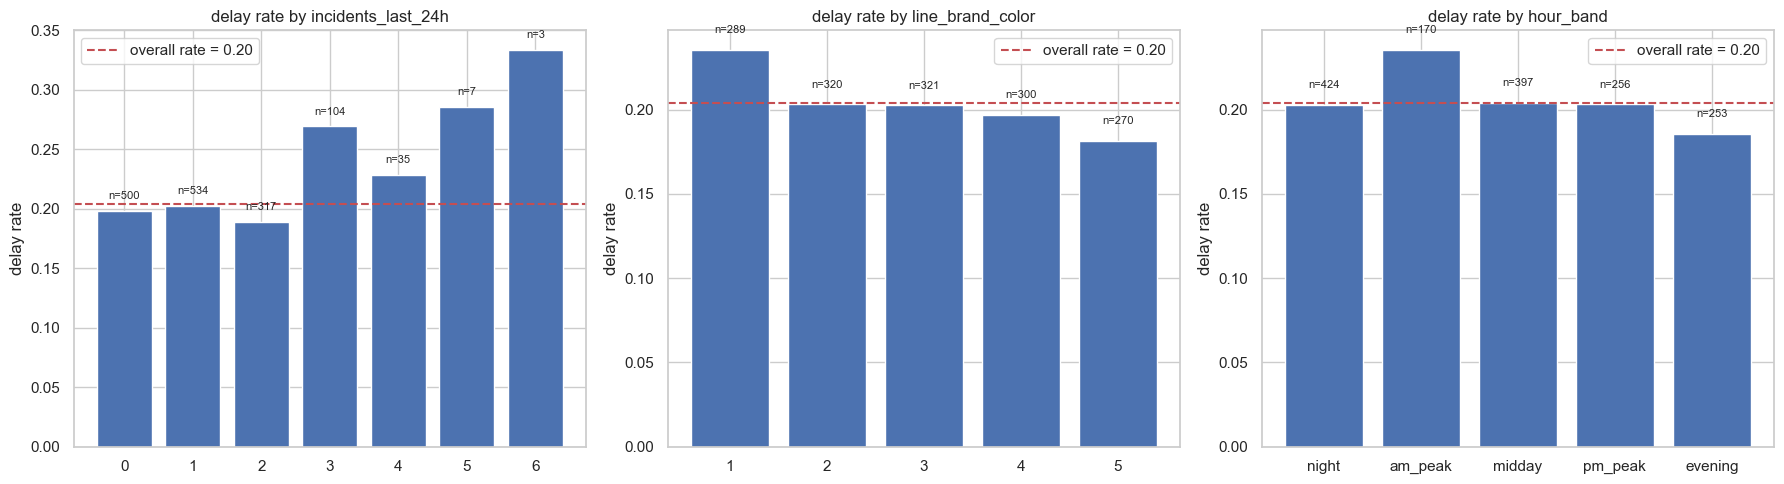

In [11]:
plot_df = train_df.copy()
plot_df["hour_band"] = pd.cut(
    plot_df["scheduled_hour"], bins=[-1, 6, 9, 15, 19, 23],
    labels=["night", "am_peak", "midday", "pm_peak", "evening"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
base_rate = plot_df["severe_delay"].mean()

for ax, col in zip(axes, ["incidents_last_24h", "line_brand_color", "hour_band"]):
    rates = plot_df.groupby(col, observed=True)["severe_delay"].mean()
    counts = plot_df.groupby(col, observed=True)["severe_delay"].size()
    ax.bar(rates.index.astype(str), rates.values, color=BLUE)
    ax.axhline(base_rate, color=RED, linestyle="--",
               label=f"overall rate = {base_rate:.2f}")
    ax.set_title(f"delay rate by {col}")
    ax.set_ylabel("delay rate")
    ax.legend()
    for i, (v, n) in enumerate(zip(rates.values, counts.values)):
        ax.text(i, v + 0.01, f"n={n}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

All three plots are essentially flat around the overall rate of 20%. The apparent jumps at 5 and 6 incidents are based on only a handful of trips (the n labels above the bars show the group sizes), so they are sampling noise, not a pattern. The delay rate varies by only a few percentage points across line colours and across time bands, with no consistent ordering. The conclusion is that these three features carry little or no usable signal, which matches their near-zero scores in 4.4 and 4.5.

### 4.8 Summary of the exploration

Four findings shape everything that follows:

1. The target is imbalanced (about 20% delays) : Accuracy is not an acceptable metric; precision, recall and ranking metrics will be used instead (Section 5).
2. Only four features carry measurable signal:`traffic_density_index`, `road_congestion_pct`, `route_length_km` and `num_stops`. The other eight look like noise under both a linear measure and a non-linear measure.
3. The signal that exists is weak : Even the best features overlap heavily between the classes, so a perfect classifier is not achievable with this data.
4. Two features are nearly duplicates (traffic density and congestion, r = 0.91). This motivates regularisation (Section 7) and forbids interpreting their individual coefficients.

## 5. Evaluation methodology

The scoring rules are fixed here, before any model is trained. Fixing them in advance prevents the (possibly unconscious) mistake of choosing, after the fact, whichever metric makes the preferred model look best.

Why accuracy is rejected. About 80% of trips are on time. A model that always predicts "on-time" reaches 80% accuracy while detecting zero delays. Accuracy is therefore reported but never used for decisions.

**The metrics used and what they mean here:**

- Precision = of the trips the model flags as delays, the fraction that really are delays. Low precision means many false alarms.

- Recall = of the real delays, the fraction the model flags. Low recall means many missed delays.

- F1= the harmonic mean of precision and recall. It is a single-number compromise between the two, used when one operating point must be picked.

- ROC-AUC = the probability that the model gives a randomly chosen delayed trip a higher score than a randomly chosen on-time trip. It evaluates the quality of the model's ranking without committing to any threshold. 0.5 is random guessing, 1.0 is perfect.

- PR-AUC (average precision) = the area under the precision-recall curve. Like ROC-AUC it is threshold-free, but it focuses on the rare positive class, which makes it the more informative summary on imbalanced data. For a random model it equals the positive rate, about 0.20 here.

Model comparison protocol. : Models are compared on ROC-AUC and PR-AUC estimated by 5-fold stratified cross-validation on the training set. Stratified means each fold keeps the 80/20 class balance, which is necessary because the positive class is rare. Cross-validation is used instead of a single split for comparisons because it averages over five different splits, so a model cannot win by luck on one particular split.

Threshold selection protocol : A single stratified 80/20 train/validation split of the training data is used for the analyses that need one fixed set of predicted probabilities: the threshold sweep, the confusion matrices, and the error analysis. The threshold is chosen on the validation part only.

Test set protocol: The test file is used exactly once, in Section 9, after the model and threshold are completely fixed. This gives an honest estimate of performance on unseen data.

## 6. Baselines

Before any real model, two trivial baselines establish the floor that any useful model must beat.

- Majority-class baseline: always predict "on-time". This baseline demonstrates concretely why accuracy is misleading on imbalanced data.
- Stratified random baseline: predict "delay" at random with probability 20%. Its ROC-AUC is 0.5 and its PR-AUC equals the delay rate by construction. These two numbers are the reference points for "no skill".

In [12]:
X = train_df.drop(columns="severe_delay")
y = train_df["severe_delay"]

majority = DummyClassifier(strategy="most_frequent").fit(X, y)
print("majority-class baseline (always predict on-time):")
print_metrics(y, majority.predict(X))
print()

stratified = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
roc_m, roc_s, pr_m, pr_s = cv_scores(stratified, X, y)
print("stratified random baseline (5-fold CV):")
print(f"  ROC-AUC = {roc_m:.3f} +/- {roc_s:.3f}")
print(f"  PR-AUC  = {pr_m:.3f} +/- {pr_s:.3f}")

majority-class baseline (always predict on-time):
  accuracy  = 0.796
  precision = 0.000
  recall    = 0.000
  F1        = 0.000

stratified random baseline (5-fold CV):
  ROC-AUC = 0.504 +/- 0.020
  PR-AUC  = 0.206 +/- 0.007


The majority-class baseline reaches 80% accuracy with precision, recall and F1 all equal to 0, because it never predicts a delay. This is the concrete demonstration that a high accuracy can hide a useless model. The stratified baseline gives ROC-AUC ≈ 0.50 and PR-AUC ≈ 0.20, the no-skill reference values. Any model below or near these numbers has learned nothing.

## 7. Logistic regression

The first real model is logistic regression. It is chosen first for three reasons:

1. It is the simplest standard model that outputs a probability rather than only a class. The dispatchers need a probability, and the threshold analysis in Section 9 needs one.
2. Its coefficients can be read directly: a positive coefficient means the feature increases the predicted delay probability.
3. It provides the linear benchmark. The exploration predicted that more flexible models will not help; logistic regression is the reference they must beat.

Three setup choices:

- Standardisation : The features are scaled to mean 0 and standard deviation 1 before the model. This is done inside a scikit-learn `Pipeline`, so during cross-validation the scaler is fitted on each training fold only and then applied to the corresponding validation fold. Fitting the scaler on all the data first would leak information from the validation folds into training, which would bias the scores upward.

- `class_weight="balanced"` makes each delayed trip weigh about four times as much as an on-time trip in the loss function, compensating for the 4-to-1 imbalance. Without it, the model would concentrate on the majority class.

- 80/20 stratified split : As stated in Section 5, a fixed validation set is created here. It is used for the probability plots, the threshold sweep and the error analysis. Model comparison still uses 5-fold cross-validation on the full training set.

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("train subset:", X_tr.shape, "| validation subset:", X_val.shape)
print(f"delay rate in train subset:      {y_tr.mean():.3f}")
print(f"delay rate in validation subset: {y_val.mean():.3f}")

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000,
                                 random_state=RANDOM_STATE)),
])

roc_m, roc_s, pr_m, pr_s = cv_scores(logreg, X, y)
print()
print("logistic regression (5-fold CV on full training set):")
print(f"  ROC-AUC = {roc_m:.3f} +/- {roc_s:.3f}")
print(f"  PR-AUC  = {pr_m:.3f} +/- {pr_s:.3f}")

train subset: (1200, 12) | validation subset: (300, 12)
delay rate in train subset:      0.204
delay rate in validation subset: 0.203

logistic regression (5-fold CV on full training set):
  ROC-AUC = 0.744 +/- 0.031
  PR-AUC  = 0.415 +/- 0.042


In [14]:
# Fit on the 80% subset and evaluate on the held-out 20% validation subset
logreg.fit(X_tr, y_tr)
p_val = logreg.predict_proba(X_val)[:, 1]      # predicted probabilities
y_val_05 = (p_val >= 0.5).astype(int)          # hard predictions at threshold 0.5

print("validation subset, threshold = 0.5:")
print_metrics(y_val, y_val_05)
print()
print(f"  ROC-AUC = {roc_auc_score(y_val, p_val):.3f}")
print(f"  PR-AUC  = {average_precision_score(y_val, p_val):.3f}")
print()

# Coefficients of the fitted model (on standardised features, so comparable)
coefs = pd.Series(logreg.named_steps["model"].coef_[0],
                  index=X.columns).sort_values(key=abs, ascending=False)
print("standardised coefficients:")
print(coefs.round(3))

validation subset, threshold = 0.5:
  accuracy  = 0.677
  precision = 0.357
  recall    = 0.738
  F1        = 0.481

  ROC-AUC = 0.755
  PR-AUC  = 0.417

standardised coefficients:
traffic_density_index          0.615
route_length_km                0.466
num_stops                      0.327
road_congestion_pct            0.227
dispatcher_experience_years   -0.207
rain_mm                        0.191
line_brand_color              -0.142
wind_speed_m_s                 0.140
incidents_last_24h             0.100
vehicle_age_years              0.091
scheduled_hour                -0.076
temperature_c                  0.009
dtype: float64


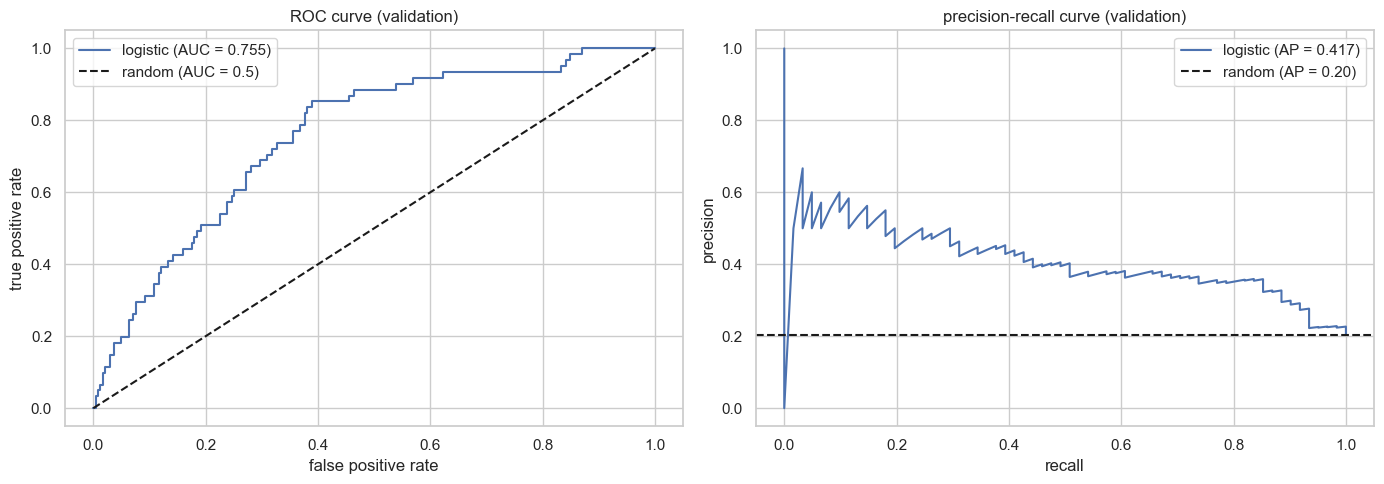

In [15]:
# ROC curve and precision-recall curve from the validation probabilities
fpr, tpr, _ = roc_curve(y_val, p_val)
prec, rec, _ = precision_recall_curve(y_val, p_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color=BLUE,
             label=f"logistic (AUC = {roc_auc_score(y_val, p_val):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="random (AUC = 0.5)")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve (validation)")
axes[0].legend()

axes[1].plot(rec, prec, color=BLUE,
             label=f"logistic (AP = {average_precision_score(y_val, p_val):.3f})")
axes[1].axhline(y_val.mean(), color="k", linestyle="--",
                label=f"random (AP = {y_val.mean():.2f})")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("precision-recall curve (validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Findings

Logistic regression clearly beats the baselines: cross-validated ROC-AUC is about 0.74 and PR-AUC about 0.41, against the no-skill values of 0.50 and 0.20. The small standard deviation across folds shows the result is stable and not an artefact of one split.

The coefficients confirm the exploration: the four largest weights (in absolute value) belong exactly to the four features identified in Section 4, all with the expected positive sign. The remaining coefficients are smaller; given that those features showed no significant relationship with the target in Sections 4.4 and 4.5, their non-zero weights should be read as the model fitting a little noise, not as real effects. Note that because traffic density and congestion are 0.91 correlated, the split of weight between those two specific coefficients is arbitrary and should not be over-interpreted (Section 4.3).

The behaviour at the default threshold of 0.5 is acceptable here only because `class_weight="balanced"` already shifts the model toward the positive class. Even so, the threshold 0.5 is just a default, not a choice; Section 9 selects the threshold deliberately based on the precision-recall trade-off.

### 7.1 Error analysis: why does the model make mistakes?

Before trying more complex models, it is useful to understand what the current model gets wrong. The most direct diagnostic is the histogram of predicted probabilities, drawn separately for trips that really were delayed and trips that were not. If the model separated the classes well, the two histograms would form two distinct groups: real delays near high probabilities and on-time trips near low probabilities.

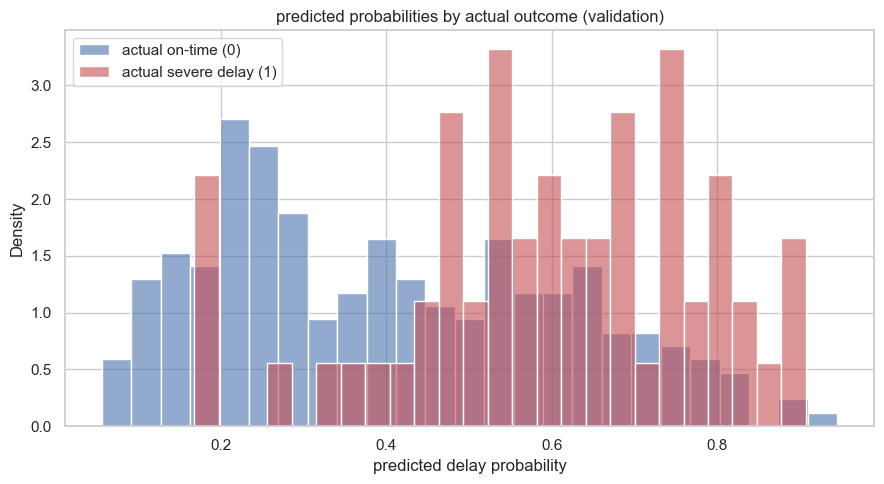

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(p_val[y_val == 0], bins=25, stat="density", color=BLUE,
             label="actual on-time (0)", alpha=0.6, ax=ax)
sns.histplot(p_val[y_val == 1], bins=25, stat="density", color=RED,
             label="actual severe delay (1)", alpha=0.6, ax=ax)
ax.set_xlabel("predicted delay probability")
ax.set_title("predicted probabilities by actual outcome (validation)")
ax.legend()
plt.tight_layout()
plt.show()

The two distributions overlap heavily. Delayed trips do receive higher probabilities on average — that is why ROC-AUC is above 0.5 — but the two groups cover mostly the same range. There is no threshold that separates them cleanly: any threshold that catches most delays will also flag many on-time trips. This is not a defect of logistic regression specifically. It is the model-level reflection of the heavy class overlap seen in the box plots of Section 4.6: the features simply do not contain enough information to separate the classes. The next two sections test whether regularisation or more flexible models can extract anything more.

## 8. Regularisation

Regularisation adds a penalty on the size of the coefficients to the training objective. There are two standard forms:

- **L2 (ridge)** penalises the sum of squared coefficients. It shrinks all coefficients smoothly toward zero and is the standard remedy when correlated features make coefficients unstable, which is exactly the situation created by the 0.91-correlated traffic pair.
- **L1 (lasso)** penalises the sum of absolute coefficients. It can set coefficients exactly to zero, which performs automatic feature selection. With eight apparent noise features, it is worth checking whether removing them helps.

In scikit-learn the strength is controlled by `C`, which is the inverse of the penalty strength: small `C` means strong regularisation. `C` is a hyperparameter, so it must be chosen by cross-validation, not on the test set. `GridSearchCV` tries every value of `C` in a grid, computes the 5-fold cross-validated ROC-AUC for each, and keeps the best. The grid covers five orders of magnitude, which is the standard way to make sure the optimum is not outside the range tried.

L1 regularisation: best C = 100, CV ROC-AUC = 0.744
L2 regularisation: best C = 0.1, CV ROC-AUC = 0.745


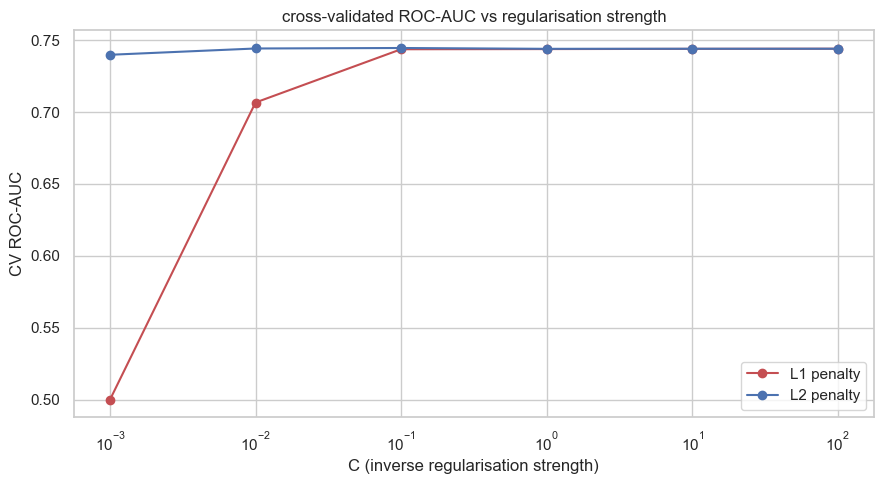

In [17]:
C_grid = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]}
reg_results = {}

for penalty in ["l1", "l2"]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty=penalty, solver="liblinear",
                                     class_weight="balanced",
                                     random_state=RANDOM_STATE)),
    ])
    grid = GridSearchCV(pipe, C_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
    grid.fit(X, y)
    reg_results[penalty] = grid
    print(f"{penalty.upper()} regularisation: best C = "
          f"{grid.best_params_['model__C']}, "
          f"CV ROC-AUC = {grid.best_score_:.3f}")

# CV score as a function of C, for both penalties
fig, ax = plt.subplots(figsize=(9, 5))
for penalty, color in [("l1", RED), ("l2", BLUE)]:
    res = reg_results[penalty].cv_results_
    ax.semilogx(C_grid["model__C"], res["mean_test_score"], "o-",
                color=color, label=f"{penalty.upper()} penalty")
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("CV ROC-AUC")
ax.set_title("cross-validated ROC-AUC vs regularisation strength")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# L1 coefficient path: number of non-zero coefficients as C decreases.
# Stronger penalty (smaller C) removes features; the ones kept longest
# are the most informative.
path_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
scaler = StandardScaler().fit(X_tr)
X_tr_scaled = scaler.transform(X_tr)

records = []
for C in path_C:
    m = LogisticRegression(penalty="l1", solver="liblinear", C=C,
                           class_weight="balanced",
                           random_state=RANDOM_STATE).fit(X_tr_scaled, y_tr)
    nz = X.columns[m.coef_[0] != 0].tolist()
    records.append({"C": C, "non-zero coefficients": len(nz),
                    "features kept": ", ".join(nz) if len(nz) <= 5 else
                                     f"{len(nz)} features"})
pd.DataFrame(records)

,C,non-zero coefficients,features kept
0,0.01,1,traffic_density_index
1,0.03,7,7 features
2,0.10,11,11 features
3,0.30,11,11 features
4,1.00,12,12 features
5,3.00,12,12 features
6,10.00,12,12 features


### Findings

The best cross-validated ROC-AUC of both penalties is essentially identical to the unregularised logistic regression (about 0.74). The exact position of the optimum inside the grid does not matter, because the score curve is flat over the moderate-to-weak range of the penalty; the score only drops when the penalty becomes strong enough to crush the informative coefficients (the left side of the plot).

This outcome is the expected one given the situation: regularisation helps when a model overfits, and with 1500 rows and only 12 features, plain logistic regression is not overfitting, so there is nothing for the penalty to fix.

The L1 path is still informative as a feature-selection check: as `C` decreases, features are removed progressively, and the very last survivor is `traffic_density_index`, the single strongest feature from Section 4. Three independent methods (correlation, mutual information, L1 selection) now agree on which features matter most, which makes that conclusion solid.

The regularised model is kept in the comparison table of Section 9, but no improvement over plain logistic regression is expected from it.

## 9. Tree-based models

The exploration (Section 4.5) predicted that there is little non-linear structure in the data. A correct analysis tests such a prediction instead of assuming it. Tree-based models are the standard tools for that test, because they can represent thresholds, curves and interactions between features (for example "long route AND heavy rain") that a linear model cannot.

Two models are tried:

- Random forest: an average of many decision trees, each trained on a random sample of the rows and a random subset of the features. The averaging reduces the variance of individual trees. The depth is limited to 5 and `class_weight="balanced"` is used, both to limit overfitting on a dataset of this size.
- Histogram gradient boosting: trees built one after another, each one correcting the errors of the previous ones. Shallow trees (depth 3) and a small learning rate (0.05) are used, which is the standard conservative configuration.

Both are compared to logistic regression with the same 5-fold cross-validation protocol from Section 5, so the comparison is fair.

In [19]:
rf = RandomForestClassifier(n_estimators=300, max_depth=5,
                            class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
gb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                    max_iter=300, random_state=RANDOM_STATE)

for name, est in [("random forest", rf), ("gradient boosting", gb)]:
    roc_m, roc_s, pr_m, pr_s = cv_scores(est, X, y)
    print(f"{name} (5-fold CV):")
    print(f"  ROC-AUC = {roc_m:.3f} +/- {roc_s:.3f}")
    print(f"  PR-AUC  = {pr_m:.3f} +/- {pr_s:.3f}")
    print()

random forest (5-fold CV):
  ROC-AUC = 0.724 +/- 0.031
  PR-AUC  = 0.388 +/- 0.034

gradient boosting (5-fold CV):
  ROC-AUC = 0.697 +/- 0.009
  PR-AUC  = 0.373 +/- 0.012



### 9.1 Feature importance

Two different importance measures are computed for the random forest. Using two measures is a safety check, because each one has a known bias.

- Impurity-based importance (built into the forest) measures how much each feature reduces the class mixing across all splits. It is fast but tends to inflate features with many distinct values.
- Permutation importance shuffles one feature at a time in the validation set and measures how much the ROC-AUC drops. If shuffling a feature does not hurt the score, the model was not really using it. This measure is computed on held-out data, so it reflects what actually helps generalisation.

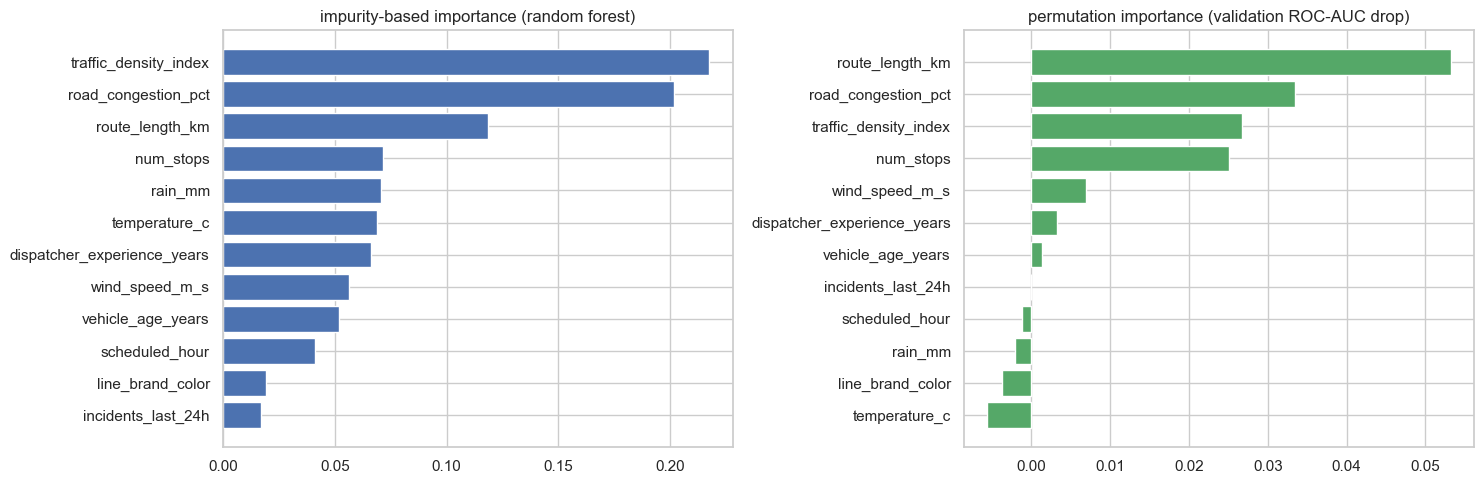

In [20]:
rf.fit(X_tr, y_tr)

impurity_imp = pd.Series(rf.feature_importances_,
                         index=X.columns).sort_values(ascending=False)

perm = permutation_importance(rf, X_val, y_val, scoring="roc_auc",
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean,
                     index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(impurity_imp.index, impurity_imp.values, color=BLUE)
axes[0].set_title("impurity-based importance (random forest)")
axes[0].invert_yaxis()
axes[1].barh(perm_imp.index, perm_imp.values, color=GREEN)
axes[1].set_title("permutation importance (validation ROC-AUC drop)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Findings

Neither tree-based model beats logistic regression. The random forest comes out about 0.02 below it in cross-validated ROC-AUC and the gradient boosting about 0.05 below. This is the direct test of the prediction from Section 4.5, and the prediction is confirmed: there is no useful non-linear structure or feature interaction in this data. The extra flexibility of the trees finds nothing to use, and on a dataset of only 1500 rows that flexibility costs some variance, which is why the trees come out lower instead of equal.

The two importance measures agree with each other and with every earlier analysis: the traffic pair dominates, the route-size pair follows, and the remaining features contribute approximately nothing (the permutation importance of the noise features is around zero, meaning shuffling them does not change the validation score). Four independent methods now give the same feature ranking.

This result also settles the model choice on simplicity grounds: when a simple interpretable model and a complex model perform the same, the simple one is preferred. The formal comparison follows in Section 10.

## 10. Model selection, threshold choice and final test

### 10.1 Model comparison

The table below puts every model on the same footing: 5-fold cross-validated ROC-AUC and PR-AUC on the training set. Comparison is done on threshold-free metrics, because comparing models at an arbitrary common threshold would mix the quality of the model with the suitability of the threshold.

In [21]:
models = {
    "stratified baseline": DummyClassifier(strategy="stratified",
                                           random_state=RANDOM_STATE),
    "logistic regression": logreg,
    "logistic + L1 (tuned)": reg_results["l1"].best_estimator_,
    "logistic + L2 (tuned)": reg_results["l2"].best_estimator_,
    "random forest": rf,
    "gradient boosting": gb,
}

rows = []
for name, est in models.items():
    roc_m, roc_s, pr_m, pr_s = cv_scores(est, X, y)
    rows.append({"model": name,
                 "ROC-AUC (CV)": f"{roc_m:.3f} +/- {roc_s:.3f}",
                 "PR-AUC (CV)":  f"{pr_m:.3f} +/- {pr_s:.3f}",
                 "_roc": roc_m})
comparison = (pd.DataFrame(rows).sort_values("_roc", ascending=False)
              .drop(columns="_roc").reset_index(drop=True))
comparison

,model,ROC-AUC (CV),PR-AUC (CV)
0,logistic + L2 (tuned),0.745 +/- 0.031,0.414 +/- 0.042
1,logistic + L1 (tuned),0.744 +/- 0.031,0.415 +/- 0.042
2,logistic regression,0.744 +/- 0.031,0.415 +/- 0.042
3,random forest,0.724 +/- 0.031,0.388 +/- 0.034
4,gradient boosting,0.697 +/- 0.009,0.373 +/- 0.012
5,stratified baseline,0.504 +/- 0.020,0.206 +/- 0.007


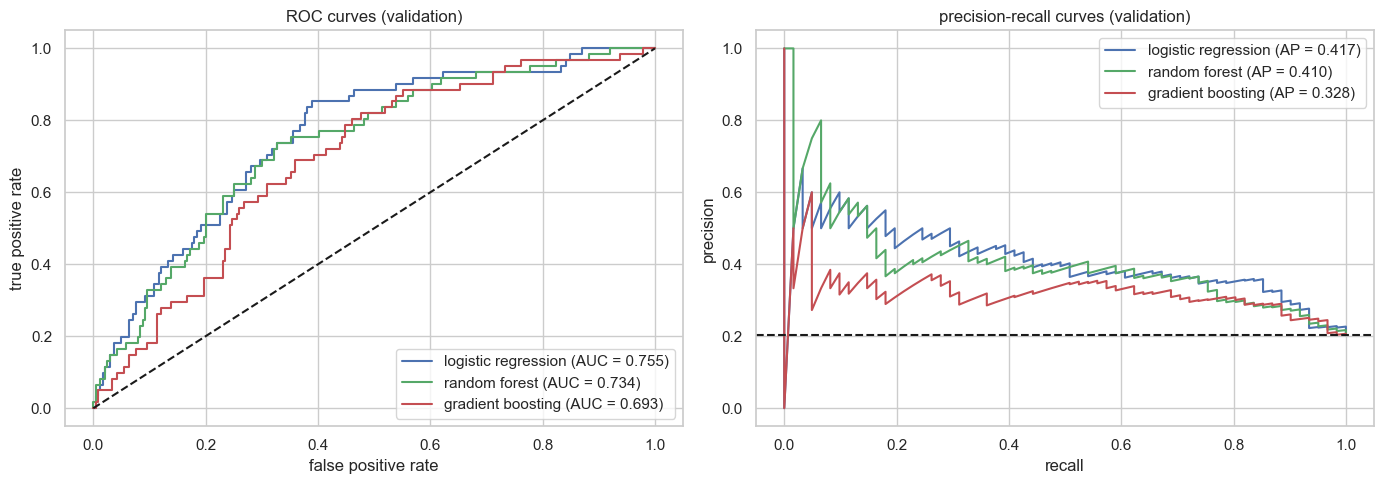

In [22]:
# Validation ROC and PR curves of the three model families, overlaid
for est in [logreg, rf, gb]:
    est.fit(X_tr, y_tr)
curve_models = {"logistic regression": (logreg, BLUE),
                "random forest": (rf, GREEN),
                "gradient boosting": (gb, RED)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, (est, color) in curve_models.items():
    p = est.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, p)
    prec, rec, _ = precision_recall_curve(y_val, p)
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{name} (AUC = {roc_auc_score(y_val, p):.3f})")
    axes[1].plot(rec, prec, color=color,
                 label=f"{name} (AP = {average_precision_score(y_val, p):.3f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curves (validation)"); axes[0].legend()
axes[1].axhline(y_val.mean(), color="k", linestyle="--")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("precision-recall curves (validation)"); axes[1].legend()
plt.tight_layout()
plt.show()

### 10.2 Confusion matrices

A single AUC number ranks the models but does not show the kinds of mistakes each one makes. The confusion matrix does: it is a 2×2 table of counts with correct on-times (true negatives, top left), false alarms (false positives, top right), missed delays (false negatives, bottom left) and caught delays (true positives, bottom right).

To compare the models fairly at the threshold level, each model is evaluated at its own F1-maximising threshold on the validation set, since the natural scale of the predicted probabilities differs between model families.

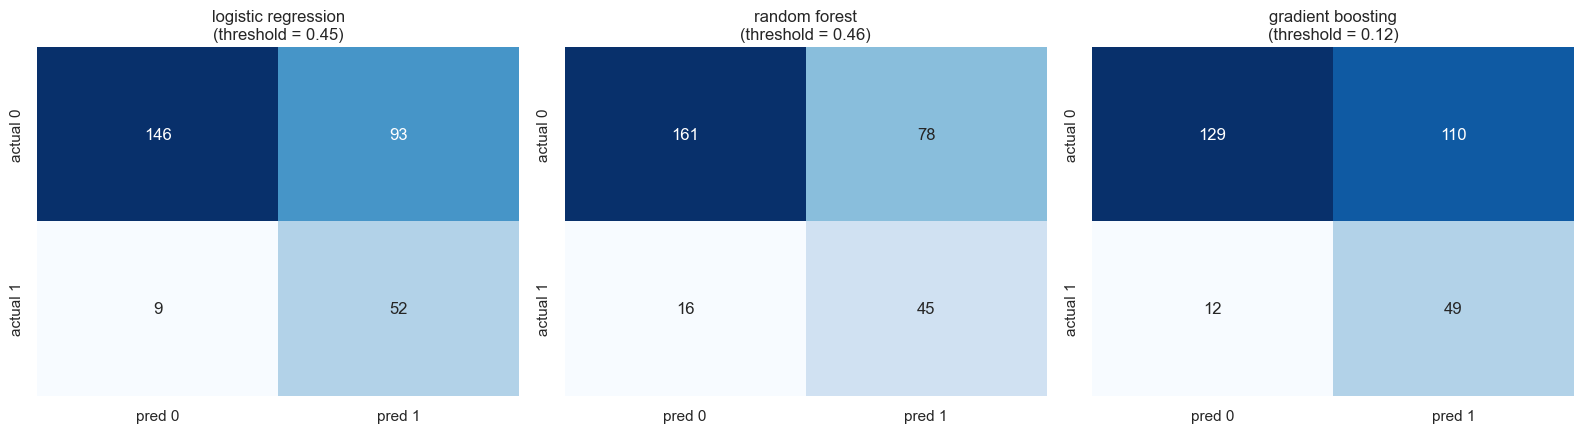

In [23]:
def best_f1_threshold(y_true, probs):
    prec, rec, thr = precision_recall_curve(y_true, probs)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return thr[int(np.nanargmax(f1[:-1]))]   # the last PR point has no threshold

cm_models = {"logistic regression": logreg,
             "random forest": rf,
             "gradient boosting": gb}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, est) in zip(axes, cm_models.items()):
    p = est.predict_proba(X_val)[:, 1]
    t = best_f1_threshold(y_val, p)
    cm = confusion_matrix(y_val, (p >= t).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["actual 0", "actual 1"])
    ax.set_title(f"{name}\n(threshold = {t:.2f})")
plt.tight_layout()
plt.show()

### 10.3 The chosen model

Logistic regression is selected. The reasons:

1. It has the highest cross-validated ROC-AUC and PR-AUC in the comparison table (the tuned regularised versions are tied with it, which is expected since regularisation changed nothing).

2. The confusion matrices show that the more flexible models do not offer a better operating point either.

3. At equal performance, the simpler model is preferred: it trains in milliseconds, has 12 readable coefficients, and is easy to monitor and retrain in production.

The wider pattern across the whole comparison is the main scientific result of this project: every model family lands at roughly the same performance level, around 0.74 ROC-AUC. When linear models, regularised linear models and two different tree ensembles all hit the same ceiling, the ceiling belongs to the data, not to the models. The features available before departure only explain part of what causes a severe delay; the rest (accidents, driver behaviour, passenger surges, etc.) is not in the dataset and no model can recover it.

### 10.4 Threshold choice

The model outputs a probability; the dispatchers need a yes/no flag. The threshold converts one into the other and is the lever that sets the operating point on the precision-recall trade-off. It is chosen here, on the validation set, before touching the test set.

The selection rule is to maximise F1 on the validation set. F1 weighs precision and recall equally, which is a defensible default in the absence of explicit costs for missed delays and false alarms. A table of nearby operating points is also shown, because in practice MetroFlow would pick the row matching its real costs rather than the mathematical optimum.

F1-maximising threshold on the validation set: t* = 0.453


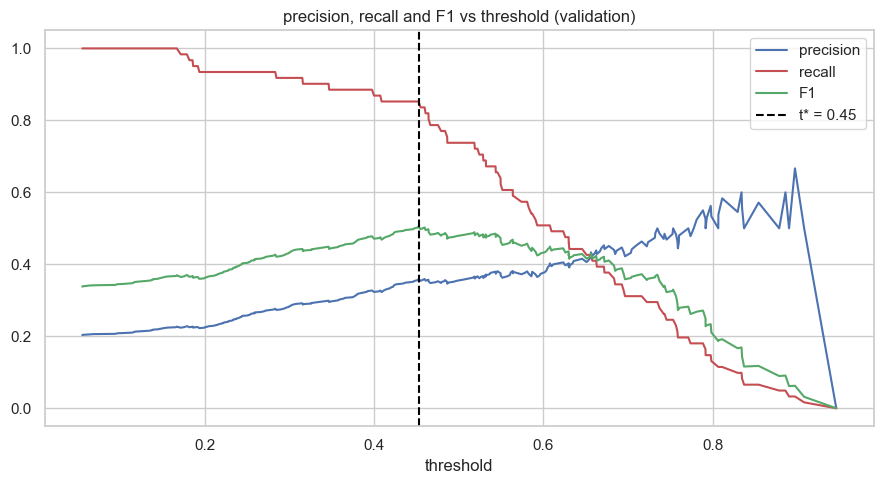

In [24]:
logreg.fit(X_tr, y_tr)
p_val = logreg.predict_proba(X_val)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1_curve[:-1]))
t_star = float(thr[best_idx])
print(f"F1-maximising threshold on the validation set: t* = {t_star:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec[:-1], color=BLUE, label="precision")
ax.plot(thr, rec[:-1], color=RED, label="recall")
ax.plot(thr, f1_curve[:-1], color=GREEN, label="F1")
ax.axvline(t_star, color="black", linestyle="--", label=f"t* = {t_star:.2f}")
ax.set_xlabel("threshold")
ax.set_title("precision, recall and F1 vs threshold (validation)")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Operating points around the chosen threshold
rows = []
for t in sorted(set([0.30, 0.40, round(t_star, 3), 0.50, 0.60, 0.70])):
    yp = (p_val >= t).astype(int)
    rows.append({"threshold": t,
                 "flags": int(yp.sum()),
                 "precision": round(precision_score(y_val, yp, zero_division=0), 3),
                 "recall": round(recall_score(y_val, yp, zero_division=0), 3),
                 "F1": round(f1_score(y_val, yp, zero_division=0), 3)})
pd.DataFrame(rows)

,threshold,flags,precision,recall,F1
0,0.300,197,0.284,0.918,0.434
1,0.400,164,0.323,0.869,0.471
2,0.453,144,0.354,0.836,0.498
3,0.500,126,0.357,0.738,0.481
4,0.600,82,0.378,0.508,0.434
5,0.700,44,0.432,0.311,0.362


The table makes the trade-off explicit and readable in operational terms. Lowering the threshold flags more trips: recall rises (fewer missed delays) but precision falls (more false alarms). Raising it does the opposite. The F1-maximising threshold is kept for the final evaluation, with the understanding that it is a default compromise: if MetroFlow decided that a missed delay costs much more than a false alarm, it would choose a lower row of this table, and the model would not need to be retrained — only the threshold would change.

### 10.5 Error analysis at the chosen threshold

The last diagnostic before the final test looks at which trips the model gets wrong. Each validation trip falls into one of four outcome groups: caught delay (TP), correct on-time (TN), false alarm (FP) or missed delay (FN). The table below shows the average value of the four informative features in each group. The purpose is to explain the errors in operational terms.

In [26]:
y_val_star = (p_val >= t_star).astype(int)
err = X_val.copy()
err["actual"] = y_val.values
err["pred"] = y_val_star

def outcome(row):
    if row["actual"] == 1 and row["pred"] == 1: return "TP (caught delay)"
    if row["actual"] == 0 and row["pred"] == 0: return "TN (correct on-time)"
    if row["actual"] == 0 and row["pred"] == 1: return "FP (false alarm)"
    return "FN (missed delay)"

err["outcome"] = err.apply(outcome, axis=1)
order = ["TN (correct on-time)", "FP (false alarm)",
         "FN (missed delay)", "TP (caught delay)"]
summary = (err.groupby("outcome")[["traffic_density_index", "road_congestion_pct",
                                   "route_length_km", "num_stops"]]
           .mean().reindex(order).round(2))
summary["count"] = err["outcome"].value_counts().reindex(order)
summary

,traffic_density_index,road_congestion_pct,route_length_km,num_stops,count
outcome,,,,,
TN (correct on-time),39.23,29.65,19.43,20.67,146
FP (false alarm),72.96,56.43,27.38,23.16,93
FN (missed delay),36.57,26.40,27.17,18.78,9
TP (caught delay),71.83,58.31,32.35,27.75,52


The error pattern matches the weak-signal story exactly:

- Missed delays (FN) are trips with relatively light traffic, low congestion and shorter routes. On the measured features they resemble ordinary on-time trips, yet they were delayed for some reason the data does not record. No model restricted to these features could catch them.
- False alarms (FP) are the mirror image: trips with heavy traffic and long routes that nevertheless arrived on time. The model flags them because they look exactly like the trips that do get delayed.

Both error types are caused by missing information, not by a fixable modelling mistake. This is consistent with the performance ceiling observed in 10.3.

### 10.6 Final evaluation on the test set

The model family (logistic regression), its hyperparameters (scikit-learn defaults with balanced class weights) and the threshold (t* from 10.4) are now completely fixed. Two final steps remain:

1. The model is retrained on the entire training set (all 1500 rows). The 80/20 split has done its job of selecting the threshold; using all available data for the final fit is standard practice and gives the model slightly more information.
2. The retrained model is evaluated once on the 400 test trips, which have not been used anywhere above.

Because the test set played no role in any decision, this number is an honest estimate of how the model would perform on future trips.

final test-set results (400 unseen trips):
  ROC-AUC = 0.763
  PR-AUC  = 0.510
  threshold used: t* = 0.453
  accuracy  = 0.618
  precision = 0.320
  recall    = 0.790
  F1        = 0.456


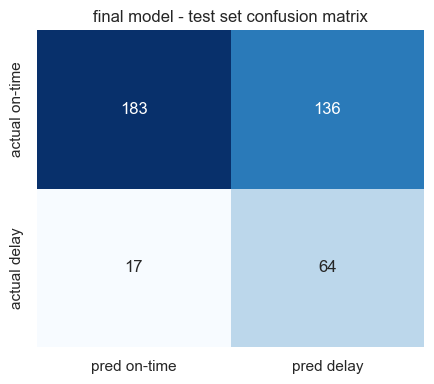

In [27]:
X_test = test_df.drop(columns="severe_delay")
y_test = test_df["severe_delay"]

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000,
                                 random_state=RANDOM_STATE)),
]).fit(X, y)

p_test = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (p_test >= t_star).astype(int)

print("final test-set results (400 unseen trips):")
print(f"  ROC-AUC = {roc_auc_score(y_test, p_test):.3f}")
print(f"  PR-AUC  = {average_precision_score(y_test, p_test):.3f}")
print(f"  threshold used: t* = {t_star:.3f}")
print_metrics(y_test, y_test_pred)

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["pred on-time", "pred delay"],
            yticklabels=["actual on-time", "actual delay"])
ax.set_title("final model - test set confusion matrix")
plt.tight_layout()
plt.show()

### Final result

The test ROC-AUC is close to the cross-validation estimate from Section 7. This agreement is the important check: it confirms that the validation methodology was sound and that no overfitting or information leakage occurred — if the test score had been clearly lower than the cross-validated score, it would have indicated that the modelling choices had been tuned to the training data. The small remaining difference between the two numbers is normal sampling variation on a test set of 400 trips.

In operational terms, at the chosen threshold the model catches the majority of the severe delays on the test set, at the cost that a substantial fraction of its alerts are false alarms. Whether that trade is worth it depends on MetroFlow's costs; the threshold table in 10.4 shows the alternatives.

## 11. Limitations, risks and deployment considerations

**Limitations**

- The data sets the ceiling, not the model : Four independent analyses (correlation, mutual information, L1 selection, permutation importance) agree that only four features carry signal, the signal is weak and approximately linear, and flexible models add nothing. A ROC-AUC around 0.75 appears to be the limit of what these features support. Better performance would require better features, not better algorithms — for example real-time vehicle positions, driver and crew data, event calendars, or live incident feeds.

- The model is trained on one fixed sample of trips. Traffic patterns, routes and timetables change over time, so the model's performance would degrade if deployed unchanged (this is called data drift).

- No temporal structure :  The rows are treated as independent trips. If the data contained trip dates, a time-based split would have been a stricter validation; with the given anonymous rows, stratified random splitting is the best available option.

- Synthetic regularity : Several feature distributions are uniform over their range, which suggests generated data. Real operational data would contain more structure (rush hours, seasons) and probably stronger signal.

**Risks in use**

- False-alarm fatigue ; At the chosen threshold a large share of alerts are wrong. If dispatchers learn to ignore the alerts, the tool loses its value. The alert volume should be tuned to what the team can act on, using the threshold table from 10.4.

- Missed delays remain, in fact, about a quarter of severe delays are not flagged. The tool must be presented as decision support, not as a guarantee, and existing manual procedures should stay in place.

**Deployment recommendations**

- Use the predicted probability in the dispatcher interface, not only the binary flag, so experienced dispatchers can apply their own judgement to borderline cases.

- Keep the threshold configurable, and revisit it with MetroFlow once the real costs of a false alarm and of a missed delay are quantified.

- Monitor performance weekly (recall, precision and alert volume against realised outcomes) and retrain on fresh data at a regular interval to counter drift.

- Log every prediction with its features, so future feature engineering can be evaluated against an honest baseline.

**Conclusion.** Severe delays can be predicted before departure with useful but modest skill (test ROC-AUC ≈ 0.75) using a plain logistic regression on four traffic and route features. More complex models do not help, because the limiting factor is the information content of the available features. The main practical lever for improvement is data collection, and the main operational lever is the choice of alert threshold.